

2. Create a simple search engine for your own photos: first, write a function that uses a CLIP model to embed all of your photos and saves the resulting vectors. Next, write a function that takes a search query (text or image), embeds it using CLIP, then finds the most similar photo embeddings and displays the corresponding photos. You can manually implement the similarity search algorithm, or a dedicated library such as the FAISS library or even a full-blown vector database.

3. Use BLIP-2 to automatically caption all of your photos.


In [1]:
import torch
import torchvision.datasets
import random
from transformers import CLIPProcessor, CLIPModel, Blip2Processor, Blip2ForConditionalGeneration
import torch.nn.functional as F

/home/damian/New Folder/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
food_photos = torchvision.datasets.Food101(root='./food_data', split='test')
my_photos = []
for i in range(100):
    my_photos.append(food_photos[random.randint(0, len(food_photos))][0])
print(my_photos[:3])

[<PIL.Image.Image image mode=RGB size=512x512 at 0x7F4ED656E510>, <PIL.Image.Image image mode=RGB size=512x512 at 0x7F4ED64DA990>, <PIL.Image.Image image mode=RGB size=512x512 at 0x7F4ED64DAAD0>]


In [10]:
clip_dir = 'openai/clip-vit-base-patch32'
clip_processor = CLIPProcessor.from_pretrained(clip_dir)
clip_model = CLIPModel.from_pretrained(clip_dir)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 28290.90it/s]


In [ ]:
inputs = clip_processor(images=my_photos, return_tensors='pt', padding=True)
with torch.no_grad():
    image_embeds = clip_model.get_image_features(**inputs)
    
image_embeds_list = F.normalize(image_embeds[1], p=2, dim=-1)

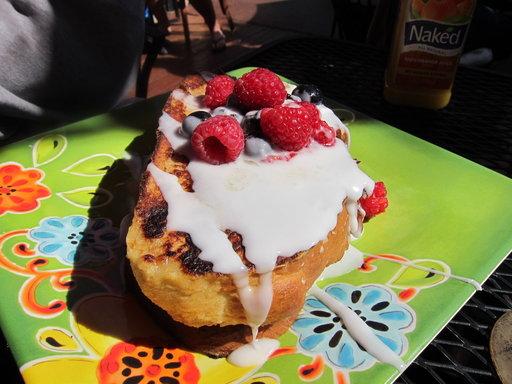

In [88]:
def get_similar_photo(query, dataset=image_embeds_list):
    inputs = clip_processor(text=[f'This is a photo of a {query}.'], return_tensors='pt', padding=True)
    with torch.no_grad():
        text_embed = clip_model.get_text_features(**inputs)
        
    text_embed_norm = F.normalize(text_embed[1], p=2, dim=-1)
    similarity = text_embed_norm @ dataset.T 
    index = similarity.argmax(dim=-1)
    return my_photos[index]
    
get_similar_photo('puncake')

## EX 3

In [3]:
blip_dir = 'Salesforce/blip2-opt-2.7b'
blip_processor = Blip2Processor.from_pretrained(blip_dir)
blip_model = Blip2ForConditionalGeneration.from_pretrained(blip_dir, device_map='auto', dtype=torch.float16)

text = []
for photo in my_photos[:3]:
    inputs = blip_processor(photo, return_tensors='pt')
    inputs = inputs.to(blip_model.device, dtype=torch.float16)
    with torch.no_grad():
        outputs = blip_model.generate(**inputs)

    text.append(blip_processor.batch_decode(outputs, skip_special_tokens=True))

text

Loading weights: 100%|██████████| 1247/1247 [00:12<00:00, 96.58it/s] 
/home/damian/New Folder/.venv/lib/python3.14/site-packages/accelerate/utils/modeling.py:1615: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(
Some parameters are on the meta device because they were offloaded to the cpu.
/home/damian/New Folder/.venv/lib/python3.14/site-packages/transformers/generation/utils.py:1638: UserWarning: Using the model-agnostic default `max_length` (=53) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


[['a bowl of fries with cheese and mushrooms\n'],
 ['a cupcake with whipped cream and red sprinkles\n'],
 ['a bowl of seafood and rice with a spoon\n']]

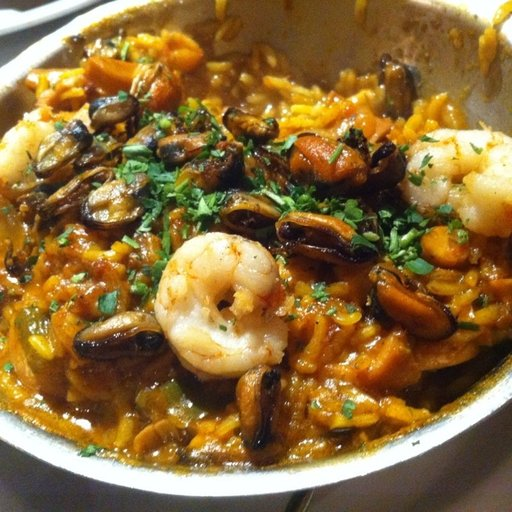

In [6]:
my_photos[2]